# Gucci Bag Price Comparison by Country
Grouped bar chart showing prices normalized to **USD** for each bag across CN, IT, FR, and US.

Exchange rates (early April 2026): 1 EUR = 1.15 USD · 1 CNY = 0.1374 USD (≈ 1/6.88)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Exchange rates to USD (early April 2026)
FX = {'USD': 1.0, 'EUR': 1.15, 'CNY': 1 / 6.88}
CURRENCY = {'US': 'USD', 'FR': 'EUR', 'IT': 'EUR', 'CN': 'CNY'}

df = pd.read_csv('data/gucci_10bags_4countries.csv')
df['price_usd'] = df.apply(lambda r: r['price'] * FX[CURRENCY[r['country']]], axis=1)
df.head()

,brand,anchor_rank_us,key,country,product_name,currency_symbol,price,product_url,status,price_usd
0,Gucci,1,A0020YAAGRB1000,US,Horsebit Ristretto medium shoulder bag,$,3350.0,https://www.gucci.com/us/en/pr/women/handbags/...,ok_from_category,3350.0
1,Gucci,2,A0022VAAG211096,US,Bamboo Tote large bag,$,4450.0,https://www.gucci.com/us/en/pr/-p-A0022VAAG211096,ok_from_category,4450.0
2,Gucci,3,853971FAF3Y2155,US,Gucci Giglio large tote bag,$,2350.0,https://www.gucci.com/us/en/pr/women/handbags/...,ok_from_category,2350.0
3,Gucci,4,866732FAFV99653,US,Borsetto medium boston bag,$,2600.0,https://www.gucci.com/us/en/pr/-p-866732FAFV99653,estimated,2600.0
4,Gucci,5,875018AAGIQ1053,US,Paparazzo medium top handle bag,$,3650.0,https://www.gucci.com/us/en/pr/women/handbags/...,ok_from_category,3650.0


In [2]:
# Pivot on USD-normalized prices
pivot = df.pivot_table(
    index=['anchor_rank_us', 'product_name'],
    columns='country',
    values='price_usd',
    aggfunc='first'
).reset_index()

pivot = pivot.sort_values('anchor_rank_us')

# Shorten long bag names for readability
pivot['short_name'] = pivot['product_name'].str.replace(
    r'\b(medium|large|mini|slim)\b', '', regex=True
).str.replace(r'\s+', ' ', regex=True).str.strip()

pivot

country,anchor_rank_us,product_name,CN,FR,IT,US,short_name
0,1,Horsebit Ristretto medium shoulder bag,3779.069767,3162.5,3162.5,3350.0,Horsebit Ristretto shoulder bag
1,2,Bamboo Tote large bag,4796.511628,4140.0,4140.0,4450.0,Bamboo Tote bag
2,3,Gucci Giglio large tote bag,2616.279070,2185.0,2185.0,2350.0,Gucci Giglio tote bag
3,4,Borsetto medium boston bag,3125.000000,2530.0,2530.0,2600.0,Borsetto boston bag
4,5,Paparazzo medium top handle bag,4142.441860,3335.0,3335.0,3650.0,Paparazzo top handle bag
5,6,Paparazzo medium top handle bag,3706.395349,2990.0,2990.0,3250.0,Paparazzo top handle bag
6,7,GG Marmont mini shoulder bag,2107.558140,1667.5,1667.5,1900.0,GG Marmont shoulder bag
7,8,Paparazzo large top handle bag,4505.813953,3680.0,3680.0,3950.0,Paparazzo top handle bag
8,9,Borsetto medium boston bag,3706.395349,2990.0,2990.0,3100.0,Borsetto boston bag
9,10,Jackie Slim medium shoulder bag,2398.255814,1897.5,1897.5,2150.0,Jackie Slim shoulder bag


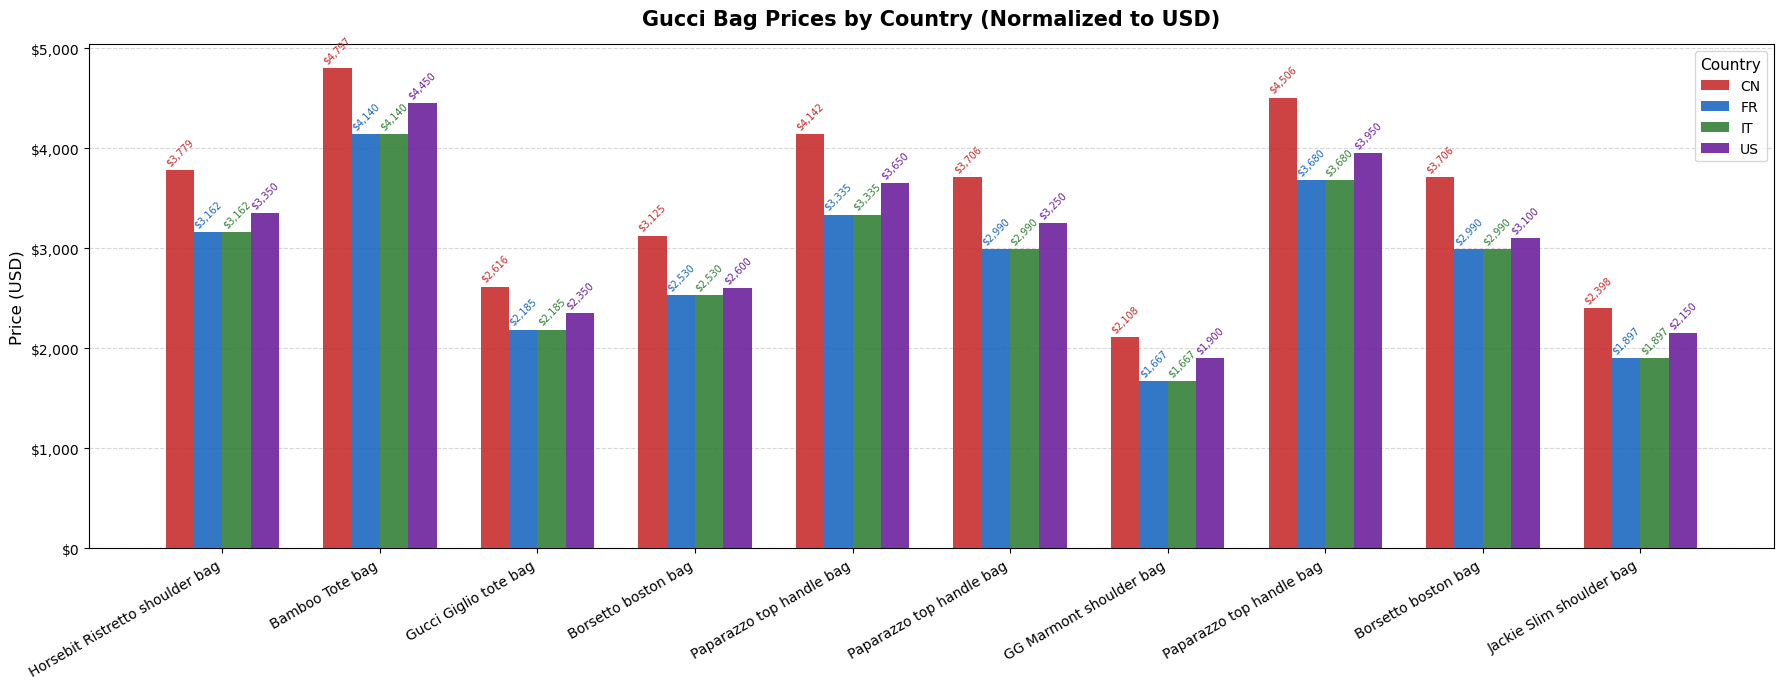

Chart saved to gucci_price_comparison.png


In [3]:
countries = ['CN', 'FR', 'IT', 'US']
colors    = {'CN': '#C62828', 'FR': '#1565C0', 'IT': '#2E7D32', 'US': '#6A1B9A'}

n_bags  = len(pivot)
n_ctry  = len(countries)
width   = 0.18
x       = np.arange(n_bags)
offsets = np.linspace(-(n_ctry - 1) / 2, (n_ctry - 1) / 2, n_ctry) * width

fig, ax = plt.subplots(figsize=(18, 7))

for offset, country in zip(offsets, countries):
    vals = pivot[country].values
    bars = ax.bar(
        x + offset, vals, width,
        label=country,
        color=colors[country], alpha=0.88, zorder=3
    )
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 30,
                f"${val:,.0f}",
                ha='center', va='bottom', fontsize=7, rotation=45, color=colors[country]
            )

ax.set_xticks(x)
ax.set_xticklabels(pivot['short_name'], rotation=30, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.set_ylabel('Price (USD)', fontsize=12)
ax.set_title('Gucci Bag Prices by Country (Normalized to USD)', fontsize=15, fontweight='bold', pad=14)
ax.legend(title='Country', fontsize=10, title_fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

fig.tight_layout()
plt.savefig('gucci_price_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to gucci_price_comparison.png')